# Experiment 4.2 — Continuous recurrent controls

Question: is the Exp4.0 gap caused by shared recurrent sequence modeling itself, or specifically by spiking dynamics / WholeCount-style readout?

Controls: bias-free tanh FF-ANN and vanilla RNN, widths 64/128, trained with endpoint CE or valid summed-logit CE on the exact same scaled Fixed250 input.

In [1]:
from pathlib import Path
import sys
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

def find_repo_root(start: Path | None = None) -> Path:
    start = (start or Path.cwd()).resolve()
    for candidate in (start, *start.parents):
        if (candidate / 'snn').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise FileNotFoundError('Could not locate writingRing repository root')

repo_root = find_repo_root()
if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
from scripts import experiment_4_2_continuous_recurrent_controls as exp42

root = exp42.results_dir(repo_root)
runs_path = root / 'runs.csv'
summary_path = root / 'summary.csv'
references_path = root / 'references.csv'
eval_dir = root / 'evaluations'
eval_count = len(list(eval_dir.glob('*.json'))) if eval_dir.exists() else 0
ready = runs_path.exists() and summary_path.exists() and references_path.exists()
print('Artifact root:', root)
print(f'Continuous-control evaluations: {eval_count}/{exp42.EXPECTED_RUNS}')
print('Finalized:', ready)
if ready:
    runs = pd.read_csv(runs_path)
    summary = pd.read_csv(summary_path)
    references = pd.read_csv(references_path)
    display(summary)
    display(references)
else:
    runs = summary = references = None
    print('Run: bash scripts/bash_script/SNN_Bash/submit_exp_4_2_cpu.bash')

Artifact root: /home/zhaolongwei_umass_edu/projects/writingRing/notebooks/artifacts/experiment_4_2_continuous_recurrent_controls/continuous_controls_v1
Continuous-control evaluations: 40/40
Finalized: True


,model_type,hidden_width,objective,primary_balanced_accuracy_mean,primary_balanced_accuracy_std,primary_macro_f1_mean,primary_macro_f1_std,tail_logit_l1_fraction_mean,tail_logit_l1_fraction_std
0,ff_ann,64,endpoint_ce,0.175591,0.025692,0.155039,0.028890,0.000000,0.000000
1,ff_ann,64,sum_logits_ce,0.434088,0.018125,0.422605,0.021126,0.000000,0.000000
2,ff_ann,128,endpoint_ce,0.174544,0.011771,0.153816,0.013896,0.000000,0.000000
3,ff_ann,128,sum_logits_ce,0.471560,0.030143,0.460584,0.032935,0.000000,0.000000
4,rnn,64,endpoint_ce,0.485761,0.016088,0.487307,0.019890,0.996217,0.050086
5,rnn,64,sum_logits_ce,0.512858,0.088052,0.506756,0.092084,0.996253,0.022198
6,rnn,128,endpoint_ce,0.503938,0.016883,0.500585,0.020367,1.046586,0.043643
7,rnn,128,sum_logits_ce,0.524111,0.042981,0.525067,0.046663,1.011167,0.044088


,method,architecture,hidden_width,tau_mem_ms,seed,test_balanced_accuracy,test_macro_f1
0,linear,linear,NaN,NaN,NaN,0.549106,0.537081
1,ff_snn,ff,64.0,1000.0,11.0,0.228130,0.203138
2,ff_snn,ff,64.0,1000.0,23.0,0.247189,0.224291
3,ff_snn,ff,64.0,1000.0,37.0,0.260666,0.229659
4,ff_snn,ff,64.0,1000.0,53.0,0.238790,0.217319
5,ff_snn,ff,64.0,1000.0,71.0,0.305309,0.279058
6,ff_snn,ff,128.0,250.0,11.0,0.294407,0.246508
7,ff_snn,ff,128.0,250.0,23.0,0.238917,0.215556
8,ff_snn,ff,128.0,250.0,37.0,0.260620,0.225170
9,ff_snn,ff,128.0,250.0,53.0,0.202932,0.177046


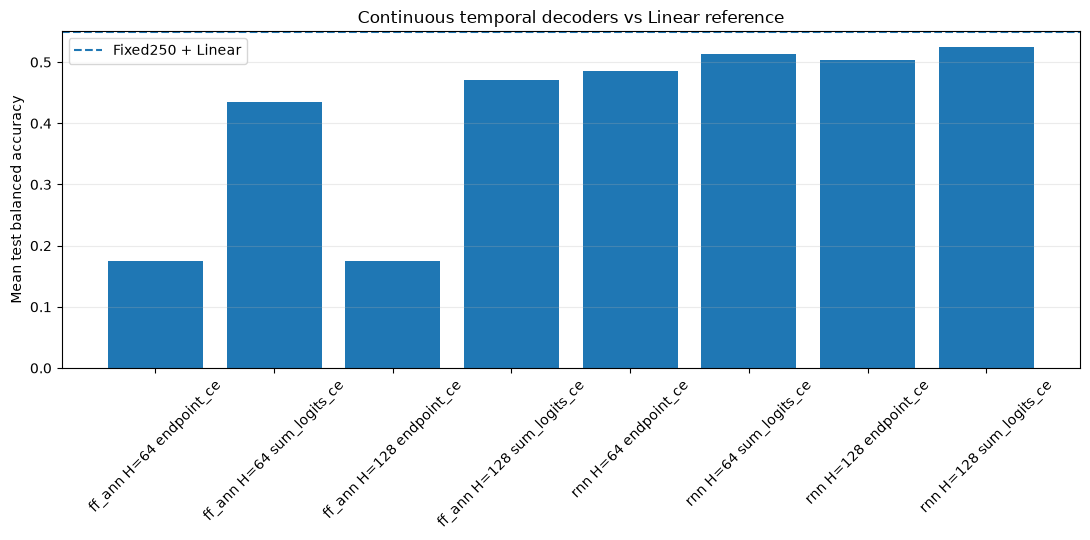

In [2]:
if not ready:
    print('Skipped: continuous-control plot requires finalized artifacts.')
else:
    test = runs[runs['split'] == 'test'].copy()
    view = (test.groupby(['model_type', 'hidden_width', 'objective'], as_index=False)
                ['primary_balanced_accuracy'].mean())
    labels = [f"{r.model_type} H={int(r.hidden_width)} {r.objective}" for r in view.itertuples()]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    ax.bar(labels, view['primary_balanced_accuracy'])
    linear_ba = references.loc[references['method'] == 'linear', 'test_balanced_accuracy'].iloc[0]
    ax.axhline(linear_ba, linestyle='--', label='Fixed250 + Linear')
    ax.set_ylabel('Mean test balanced accuracy')
    ax.set_title('Continuous temporal decoders vs Linear reference')
    ax.tick_params(axis='x', rotation=45)
    ax.legend()
    ax.grid(True, axis='y', alpha=0.25)
    plt.tight_layout()
    plt.show()

In [3]:
if not ready:
    print('Skipped: objective/readout comparison requires finalized artifacts.')
else:
    test = runs[runs['split'] == 'test'].copy()
    cols = ['model_type', 'hidden_width', 'objective', 'primary_balanced_accuracy',
            'endpoint_logits_balanced_accuracy', 'valid_sum_logits_balanced_accuracy',
            'full_sum_logits_balanced_accuracy', 'tail_logit_l1_fraction']
    display(test.groupby(['model_type', 'hidden_width', 'objective'])[cols[3:]].agg(['mean', 'std']))
    display(references.groupby(['method', 'hidden_width', 'tau_mem_ms'], dropna=False)
            [['test_balanced_accuracy', 'test_macro_f1']].agg(['mean', 'std']))

primary_balanced_accuracy            \
                                                           mean       std   
model_type hidden_width objective                                           
ff_ann     64           endpoint_ce                    0.175591  0.025692   
                        sum_logits_ce                  0.434088  0.018125   
           128          endpoint_ce                    0.174544  0.011771   
                        sum_logits_ce                  0.471560  0.030143   
rnn        64           endpoint_ce                    0.485761  0.016088   
                        sum_logits_ce                  0.512858  0.088052   
           128          endpoint_ce                    0.503938  0.016883   
                        sum_logits_ce                  0.524111  0.042981   

                                      endpoint_logits_balanced_accuracy  \
                                                                   mean   
model_type hidden_width objective                                         
ff_ann     64           endpoint_ce                            0.175591   
                        sum_logits_ce                          0.114026   
           128          endpoint_ce                            0.174544   
                        sum_logits_ce                          0.117045   
rnn        64           endpoint_ce                            0.485761   
                        sum_logits_ce                          0.474122   
           128          endpoint_ce                            0.503938   
                        sum_logits_ce                          0.507062   

                                                 \
                                            std   
model_type hidden_width objective                 
ff_ann     64           endpoint_ce    0.025692   
                        sum_logits_ce  0.012436   
           128          endpoint_ce    0.011771   
                        sum_logits_ce  0.013055   
rnn        64           endpoint_ce    0.016088   
                        sum_logits_ce  0.061984   
           128          endpoint_ce    0.016883   
                        sum_logits_ce  0.066294   

                                      valid_sum_logits_balanced_accuracy  \
                                                                    mean   
model_type hidden_width objective                                          
ff_ann     64           endpoint_ce                             0.143140   
                        sum_logits_ce                           0.434088   
           128          endpoint_ce                             0.124326   
                        sum_logits_ce                           0.471560   
rnn        64           endpoint_ce                             0.204973   
                        sum_logits_ce                           0.512858   
           128          endpoint_ce                             0.226825   
                        sum_logits_ce                           0.524111   

                                                 \
                                            std   
model_type hidden_width objective                 
ff_ann     64           endpoint_ce    0.016766   
                        sum_logits_ce  0.018125   
           128          endpoint_ce    0.017307   
                        sum_logits_ce  0.030143   
rnn        64           endpoint_ce    0.053544   
                        sum_logits_ce  0.088052   
           128          endpoint_ce    0.019842   
                        sum_logits_ce  0.042981   

                                      full_sum_logits_balanced_accuracy  \
                                                                   mean   
model_type hidden_width objective                                         
ff_ann     64           endpoint_ce                            0.143140   
                        sum_logits_ce                          0.434088   
           128          endp

test_balanced_accuracy            \
                                                   mean       std   
method   hidden_width tau_mem_ms                                    
ff_snn   64.0         1000.0                   0.256017  0.030015   
         128.0        250.0                    0.247563  0.033449   
linear   NaN          NaN                      0.549106       NaN   
rsnn_snn 64.0         1000.0                   0.340511  0.030960   
         128.0        250.0                    0.349288  0.045759   

                                 test_macro_f1            
                                          mean       std  
method   hidden_width tau_mem_ms                          
ff_snn   64.0         1000.0          0.230693  0.028807  
         128.0        250.0           0.218625  0.025802  
linear   NaN          NaN             0.537081       NaN  
rsnn_snn 64.0         1000.0          0.339472  0.041429  
         128.0        250.0           0.341719  0.053809